#Demonstration: Supervised Learning - Regression

##Scenario:
- A real estate agency wants to estimate house prices in California based on various factors like location, number of rooms, and population density. They employ different machine learning models to predict prices and compare their predictions with actual market values to determine the most accurate approach.

##Step 1: Load and Explore the Dataset
We use the California Housing Dataset to train and test the model to see the models's Performance

A Pandas DataFrame is created to store the dataset.

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

# Display dataset sample
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


##Step 2: Preprocessing Data
Features (X) are selected by removing the target variable (Price).

Data is standardized using StandardScaler to ensure all features are on the same scale.

In [2]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Price'])
y = df['Price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data has been standardized.")

Data has been standardized.


##Step 3: Check for Multicollinearity
Variance Inflation Factor (VIF) helps detect multicollinearity among features.

If a feature has a high VIF (>5 or >10), it indicates redundancy.

In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

print("Variance Inflation Factor (VIF) for each feature:")
print(vif_data)

Variance Inflation Factor (VIF) for each feature:
      Feature       VIF
0      MedInc  2.501295
1    HouseAge  1.241254
2    AveRooms  8.342786
3   AveBedrms  6.994995
4  Population  1.138125
5    AveOccup  1.008324
6    Latitude  9.297624
7   Longitude  8.962263


##Step 4: Train-Test Split
The dataset is split into 80% training data and 20% testing data.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")

Data split into training and testing sets.


##Step 5: Train Multiple Regression Models
Various regression models are trained, including Linear Regression, Ridge, Lasso, ElasticNet, SVR, Decision Trees, and Gradient Boosting.

In [5]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "ElasticNet Regression": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "Support Vector Regression": SVR(),
    "Decision Tree Regression": DecisionTreeRegressor(),
    "Random Forest Regression": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting Regression": GradientBoostingRegressor()
}

print("Regression models initialized.")

Regression models initialized.


##Step 6: Train and Evaluate Each Model
Models are trained on X_train and y_train.

Predictions are made on X_test.

Models are evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), RMSE, and R-Square (R²).

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

for name, model in models.items():
    model.fit(X_train, y_train)  # Train model
    y_pred = model.predict(X_test)  # Make predictions

    # Calculate performance metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, rmse, r2])

print("Model training and evaluation complete.")

Model training and evaluation complete.


##Step 7: Compare Model Performance
A DataFrame is created to display performance metrics.

RMSE is plotted to visually compare model performance.

                          Model       MAE       MSE      RMSE  R-Square
0             Linear Regression  0.533200  0.555892  0.745581  0.575788
1              Ridge Regression  0.533193  0.555851  0.745554  0.575819
2              Lasso Regression  0.622148  0.679552  0.824349  0.481420
3         ElasticNet Regression  0.596967  0.635761  0.797346  0.514838
4     Support Vector Regression  0.397763  0.355198  0.595985  0.728941
5      Decision Tree Regression  0.458187  0.502678  0.708998  0.616396
6      Random Forest Regression  0.327500  0.254257  0.504239  0.805972
7  Gradient Boosting Regression  0.371636  0.293936  0.542159  0.775691


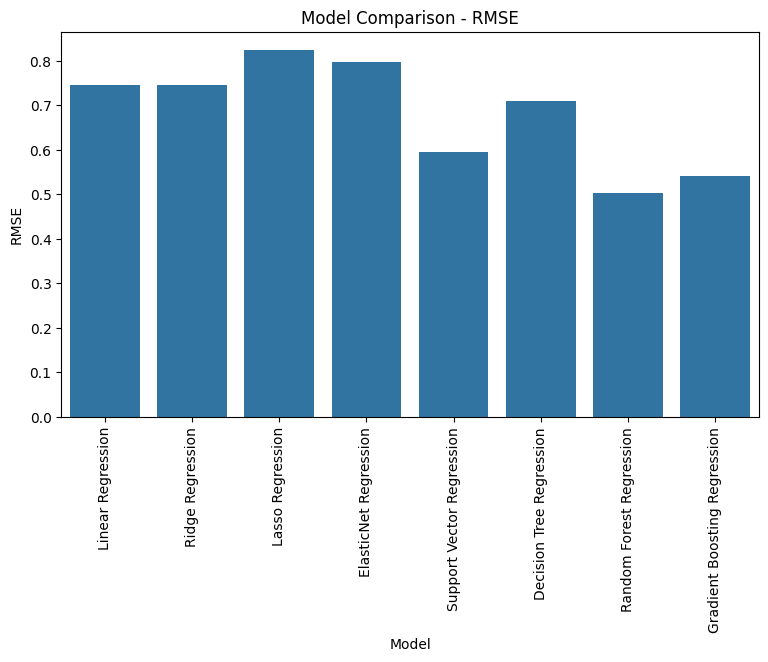

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

df_results = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R-Square"])
print(df_results)

# Plot comparison
plt.figure(figsize=(9, 5))
sns.barplot(x='Model', y='RMSE', data=df_results)
plt.xticks(rotation=90)
plt.title("Model Comparison - RMSE")
plt.show()

##Step 8: Train a Final Model (Best Performing)
Based on the results, we select Random Forest Regression as the best model.

We train it again and make final predictions.

In [8]:
best_model = RandomForestRegressor(n_estimators=100)
best_model.fit(X_train, y_train)
final_predictions = best_model.predict(X_test)

# Final model evaluation
final_mae = mean_absolute_error(y_test, final_predictions)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, final_predictions)

print("Final Model Performance (Random Forest Regression):")
print(f"MAE: {final_mae}")
print(f"MSE: {final_mse}")
print(f"RMSE: {final_rmse}")
print(f"R-Square: {final_r2}")

Final Model Performance (Random Forest Regression):
MAE: 0.32627778723352724
MSE: 0.25381848039475685
RMSE: 0.5038040099034116
R-Square: 0.8063059055536355


- The dataset was preprocessed, scaled, and split into training/testing sets.

- Various regression models were trained and evaluated.

- The best-performing model (Random Forest Regression) was selected and retrained.

- The final model was evaluated using MAE, MSE, RMSE, and R².

##Step 9: Training Model for Predicting Price

In [13]:
import warnings
# Suppress warnings
warnings.simplefilter(action='ignore', category=UserWarning)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=100),
    "Support Vector Regressor": SVR(),
}

# Train all models
for name, model in models.items():
    model.fit(X_train, y_train)

##Step 10: Predicting House Prices

In [14]:
# Predict on test set
predictions = {}
print("Predicted vs Actual Prices:")
for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # Display first 5 predictions vs actual prices
    print(f"{name} Predictions:")
    comparison_df = pd.DataFrame({"Actual Price": y_test[:5].values, "Predicted Price": y_pred[:5]})
    print(comparison_df)
    print("-")

Predicted vs Actual Prices:
Linear Regression Predictions:
   Actual Price  Predicted Price
0       0.47700         0.719123
1       0.45800         1.764017
2       5.00001         2.709659
3       2.18600         2.838926
4       2.78000         2.604657
-
Decision Tree Regressor Predictions:
   Actual Price  Predicted Price
0       0.47700          0.42100
1       0.45800          1.20300
2       5.00001          5.00001
3       2.18600          2.17000
4       2.78000          2.25700
-
Random Forest Regressor Predictions:
   Actual Price  Predicted Price
0       0.47700         0.487910
1       0.45800         0.704450
2       5.00001         4.861927
3       2.18600         2.511210
4       2.78000         2.348250
-
Gradient Boosting Regressor Predictions:
   Actual Price  Predicted Price
0       0.47700         0.505188
1       0.45800         1.093346
2       5.00001         4.245710
3       2.18600         2.545174
4       2.78000         2.279103
-
Support Vector Regressor P